In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [2]:
data = pd.read_csv('/content/drug_discovery_virtual_screening.csv')

In [3]:
data.head()

,compound_id,protein_id,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction,binding_affinity,active
0,CID_00000,PID_361,499.671415,2.487233,1,7,4,113.350817,4.050696,678,6.019657,0.812534,12.512165,0.736978,14.972288,5.996665,0
1,CID_00001,PID_165,436.173570,3.283222,3,4,4,71.981132,3.704408,876,6.447408,0.651417,11.538420,0.497915,21.168271,6.445742,0
2,CID_00002,PID_168,514.768854,NaN,2,11,11,83.936307,1.869610,658,3.925837,0.633467,13.155702,0.782323,9.074061,5.689583,0
3,CID_00003,PID_226,602.302986,3.038058,0,5,5,79.868125,2.451909,312,7.597056,0.513038,12.071822,1.930458,23.080293,6.043438,0
4,CID_00004,PID_224,426.584663,0.659578,2,4,5,88.198676,1.771936,1418,4.249454,0.613571,15.850448,0.300835,2.802846,4.845055,0


In [4]:
data.shape

(2000, 17)

In [5]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 2000


In [6]:
data.columns

Index(['compound_id', 'protein_id', 'molecular_weight', 'logp',
       'h_bond_donors', 'h_bond_acceptors', 'rotatable_bonds',
       'polar_surface_area', 'compound_clogp', 'protein_length', 'protein_pi',
       'hydrophobicity', 'binding_site_size', 'mw_ratio',
       'logp_pi_interaction', 'binding_affinity', 'active'],
      dtype='object')

In [7]:
data.dtypes

,0
compound_id,object
protein_id,object
molecular_weight,float64
logp,float64
h_bond_donors,int64
h_bond_acceptors,int64
rotatable_bonds,int64
polar_surface_area,float64
compound_clogp,float64
protein_length,int64


In [8]:
for col in data.columns:
    temp_null_count = data[data[col].isnull()].shape[0]
    print('{} - {}'.format(col, temp_null_count))

compound_id - 0
protein_id - 0
molecular_weight - 0
logp - 60
h_bond_donors - 0
h_bond_acceptors - 0
rotatable_bonds - 0
polar_surface_area - 60
compound_clogp - 0
protein_length - 0
protein_pi - 0
hydrophobicity - 60
binding_site_size - 0
mw_ratio - 0
logp_pi_interaction - 0
binding_affinity - 0
active - 0


In [9]:
data.describe()

,molecular_weight,logp,h_bond_donors,h_bond_acceptors,rotatable_bonds,polar_surface_area,compound_clogp,protein_length,protein_pi,hydrophobicity,binding_site_size,mw_ratio,logp_pi_interaction,binding_affinity,active
count,2000.000000,1940.000000,2000.000000,2000.000000,2000.00000,1940.000000,2000.000000,2000.00000,2000.000000,1940.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,456.772168,3.479480,1.961000,5.115000,5.96850,80.026470,2.813403,848.92600,6.460332,0.645325,15.155982,0.708989,22.598329,6.531228,0.304000
std,104.874658,1.638638,1.348105,2.330985,2.40778,25.344944,1.188590,380.83777,1.210236,0.095419,2.997837,0.475588,10.918200,1.194584,0.460098
min,50.307070,-4.325172,0.000000,0.000000,0.00000,-24.653688,-1.426170,201.00000,2.597565,0.332013,4.655871,0.097804,-6.624581,1.990381,0.000000
25%,388.747480,2.419505,1.000000,3.000000,4.00000,63.166240,2.006000,509.50000,5.615083,0.577986,13.144847,0.383770,14.826016,5.856086,0.000000
50%,454.869085,3.501416,2.000000,5.000000,6.00000,80.606617,2.773587,844.00000,6.473527,0.647452,15.237835,0.532021,21.858904,6.480304,0.000000
75%,520.982885,4.518801,3.000000,7.000000,7.00000,97.366501,3.620260,1192.00000,7.270822,0.711428,17.184475,0.867184,29.526168,7.164685,1.000000
max,994.048532,9.978489,8.000000,15.000000,17.00000,159.627362,6.891681,1499.00000,10.266937,0.978030,24.887713,3.403706,76.998672,15.039709,1.000000


In [10]:
data['active'].unique()

array([0, 1])

/tmp/ipykernel_491/4209725946.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['molecular_weight'].dropna(), ax=ax)


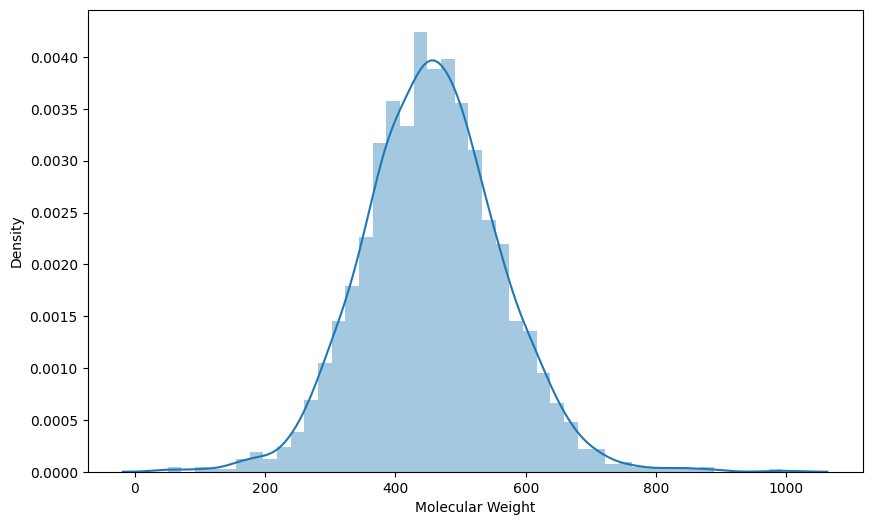

In [11]:
fig, ax = plt.subplots(figsize=(10,6))
sns.distplot(data['molecular_weight'].dropna(), ax=ax)
ax.set_xlabel('Molecular Weight')
ax.set_ylabel('Density')
plt.show()

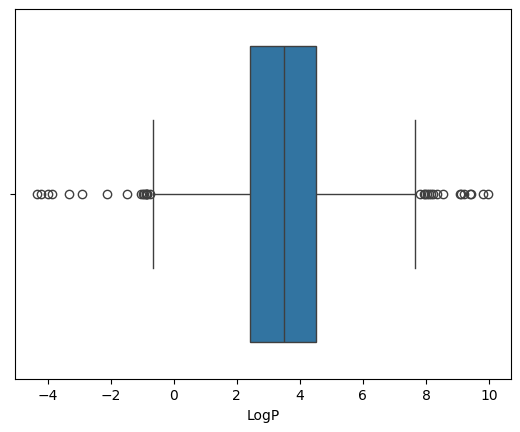

In [12]:
sns.boxplot(x=data['logp'])
plt.xlabel('LogP')
plt.show()

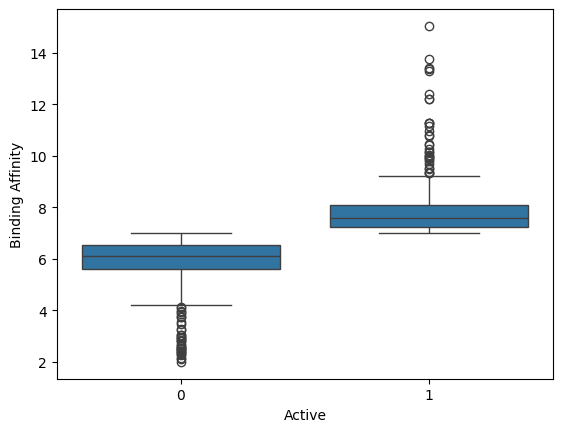

In [13]:
sns.boxplot(x='active', y='binding_affinity', data=data)
plt.xlabel('Active')
plt.ylabel('Binding Affinity')
plt.show()

In [14]:
data_clean = data.copy()

In [15]:
numeric_cols = data_clean.select_dtypes(include=[np.number]).columns.tolist()

In [16]:
outliers_before = {}
for col in numeric_cols:
    if data_clean[col].notna().sum() > 0:
        Q1 = data_clean[col].quantile(0.25)
        Q3 = data_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = ((data_clean[col] < lower_bound) | (data_clean[col] > upper_bound)).sum()
        outliers_before[col] = outliers
        print(f"{col}: {outliers} выбросов ({outliers/len(data_clean)*100:.2f}%)")

molecular_weight: 34 выбросов (1.70%)
logp: 32 выбросов (1.60%)
h_bond_donors: 4 выбросов (0.20%)
h_bond_acceptors: 3 выбросов (0.15%)
rotatable_bonds: 46 выбросов (2.30%)
polar_surface_area: 6 выбросов (0.30%)
compound_clogp: 15 выбросов (0.75%)
protein_length: 0 выбросов (0.00%)
protein_pi: 10 выбросов (0.50%)
hydrophobicity: 9 выбросов (0.45%)
binding_site_size: 14 выбросов (0.70%)
mw_ratio: 144 выбросов (7.20%)
logp_pi_interaction: 17 выбросов (0.85%)
binding_affinity: 66 выбросов (3.30%)
active: 0 выбросов (0.00%)


In [17]:
for col in numeric_cols:
    if data_clean[col].notna().sum() > 0:
        Q1 = data_clean[col].quantile(0.25)
        Q3 = data_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        data_clean.loc[data_clean[col] < lower_bound, col] = lower_bound
        data_clean.loc[data_clean[col] > upper_bound, col] = upper_bound

/tmp/ipykernel_491/98050470.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_clean.loc[data_clean[col] < lower_bound, col] = lower_bound
/tmp/ipykernel_491/98050470.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-514.25' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_clean.loc[data_clean[col] < lower_bound, col] = lower_bound
/tmp/ipykernel_491/98050470.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-1.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_clean.loc[data_clean[col] < lower_bound, col] = lower_bound


In [18]:
outliers_after = {}
for col in numeric_cols:
    if data_clean[col].notna().sum() > 0:
        Q1 = data_clean[col].quantile(0.25)
        Q3 = data_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = ((data_clean[col] < lower_bound) | (data_clean[col] > upper_bound)).sum()
        outliers_after[col] = outliers
        print(f"{col}: {outliers} выбросов ({outliers/len(data_clean)*100:.2f}%)")

molecular_weight: 0 выбросов (0.00%)
logp: 0 выбросов (0.00%)
h_bond_donors: 0 выбросов (0.00%)
h_bond_acceptors: 0 выбросов (0.00%)
rotatable_bonds: 0 выбросов (0.00%)
polar_surface_area: 0 выбросов (0.00%)
compound_clogp: 0 выбросов (0.00%)
protein_length: 0 выбросов (0.00%)
protein_pi: 0 выбросов (0.00%)
hydrophobicity: 0 выбросов (0.00%)
binding_site_size: 0 выбросов (0.00%)
mw_ratio: 0 выбросов (0.00%)
logp_pi_interaction: 0 выбросов (0.00%)
binding_affinity: 0 выбросов (0.00%)
active: 0 выбросов (0.00%)


In [19]:
if numeric_cols:
    imp_median = SimpleImputer(strategy='median')
    data_clean[numeric_cols] = imp_median.fit_transform(data_clean[numeric_cols])

In [20]:
data_clean = data_clean.drop(['compound_id', 'protein_id'], axis=1)

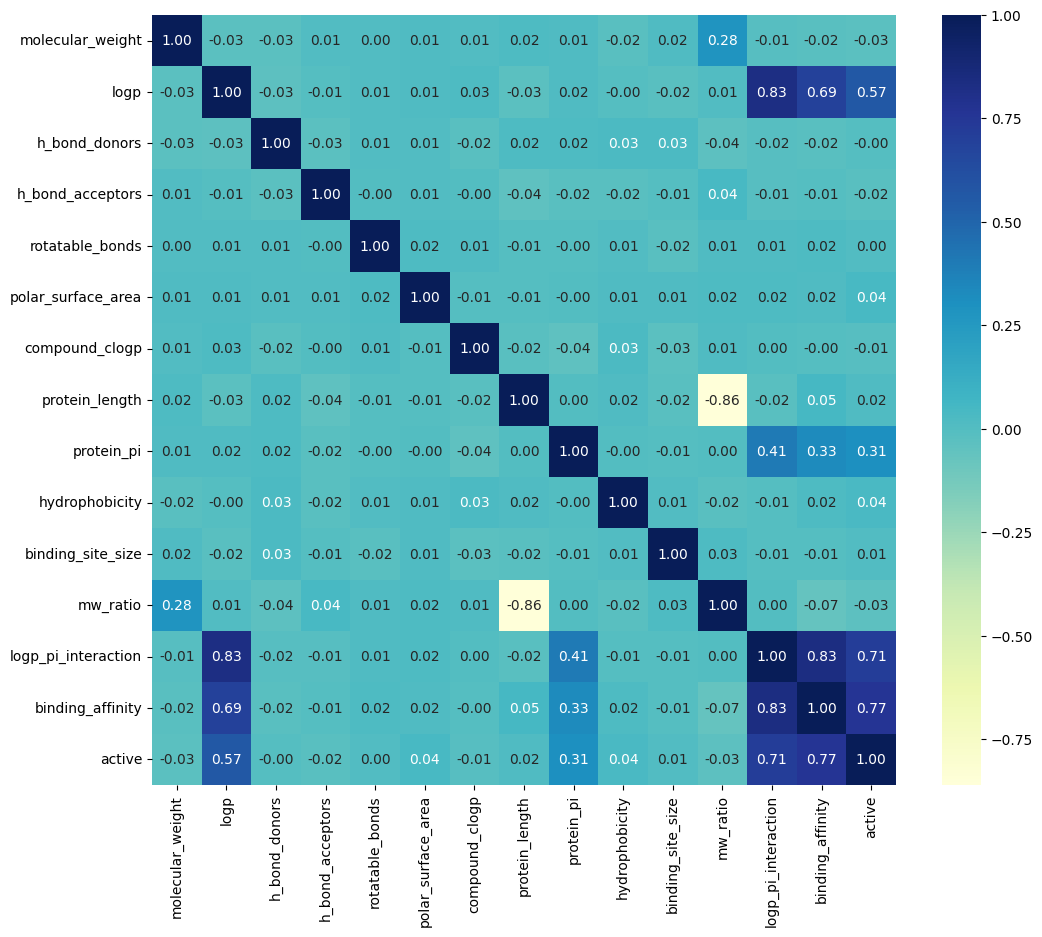

In [21]:
plt.figure(figsize=(12, 10))
corr_matrix = data_clean.corr()
sns.heatmap(corr_matrix, cmap='YlGnBu', annot=True, fmt='.2f')
plt.show()

In [22]:
X = data_clean.drop('active', axis=1)

In [23]:
y = data_clean['active']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, shuffle=True, random_state=42
)

In [25]:
scaler = StandardScaler()

In [26]:
X_train_scaled = scaler.fit_transform(X_train)

In [27]:
X_test_scaled = scaler.transform(X_test)

In [28]:
n_features = X_train.shape[1]

In [29]:
model = Sequential()
model.add(Dense(20, activation='relu', input_shape=(n_features,)))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [31]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=32,
    verbose=1,
    validation_data=(X_test_scaled, y_test)
)

Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6803 - loss: 0.5552 - val_accuracy: 0.7360 - val_loss: 0.4549
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7764 - loss: 0.4110 - val_accuracy: 0.8480 - val_loss: 0.3652
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8930 - loss: 0.3137 - val_accuracy: 0.8880 - val_loss: 0.2986
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9026 - loss: 0.2677 - val_accuracy: 0.9160 - val_loss: 0.2480
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9316 - loss: 0.1987 - val_accuracy: 0.9200 - val_loss: 0.2134
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9356 - loss: 0.1741 - val_accuracy: 0.9300 - val_loss: 0.1891
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9675 - loss: 0.1318 - val_accuracy: 0.9360 - val_loss: 0.1710
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9527 - loss: 0.1382 - val_accuracy: 0.9360 - val_loss

In [32]:
from matplotlib import pyplot

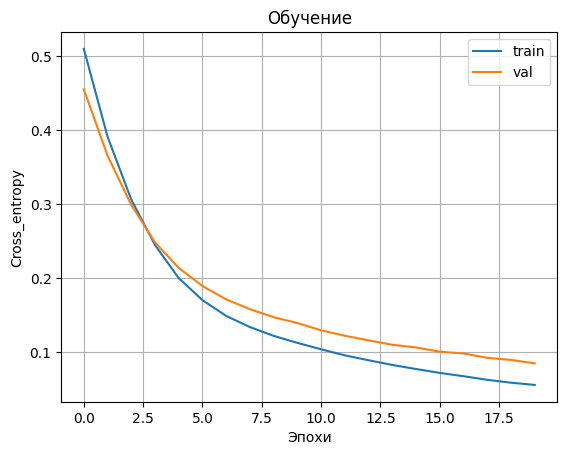

In [33]:
pyplot.title('Обучение')
pyplot.xlabel('Эпохи')
pyplot.ylabel('Cross_entropy')
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='val')
pyplot.legend()
pyplot.grid(True)
pyplot.show()

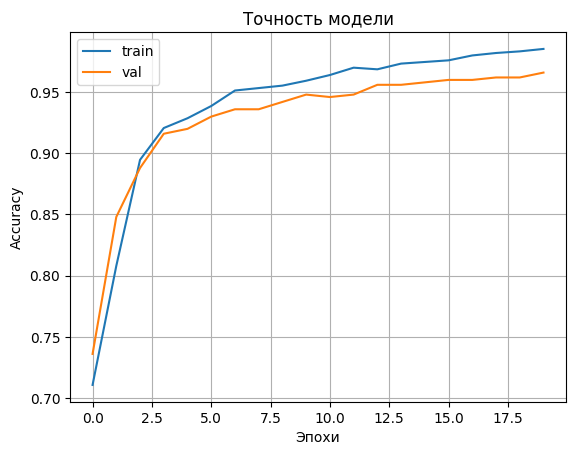

In [34]:
pyplot.title('Точность модели')
pyplot.xlabel('Эпохи')
pyplot.ylabel('Accuracy')
pyplot.plot(history.history['accuracy'], label='train')
pyplot.plot(history.history['val_accuracy'], label='val')
pyplot.legend()
pyplot.grid(True)
pyplot.show()

In [35]:
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [36]:
score = accuracy_score(y_test, y_pred)

In [37]:
print('Accuracy на тестовой выборке:', score)

Accuracy на тестовой выборке: 0.966


In [38]:
kfold = StratifiedKFold(5, shuffle=True, random_state=42)
scores = []

In [39]:
for train_ix, test_ix in kfold.split(X, y):
    X_train_cv, X_test_cv = X.iloc[train_ix], X.iloc[test_ix]
    y_train_cv, y_test_cv = y.iloc[train_ix], y.iloc[test_ix]

    scaler_cv = StandardScaler()
    X_train_scaled_cv = scaler_cv.fit_transform(X_train_cv)
    X_test_scaled_cv = scaler_cv.transform(X_test_cv)

    model_cv = Sequential()
    model_cv.add(Dense(20, activation='relu', input_shape=(n_features,)))
    model_cv.add(Dense(10, activation='relu'))
    model_cv.add(Dense(1, activation='sigmoid'))

    model_cv.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    model_cv.fit(
        X_train_scaled_cv, y_train_cv,
        epochs=20,
        batch_size=32,
        verbose=0
    )

    y_pred_cv_prob = model_cv.predict(X_test_scaled_cv)
    y_pred_cv = (y_pred_cv_prob > 0.5).astype(int)

    score_cv = accuracy_score(y_test_cv, y_pred_cv)

    scores.append(score_cv)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [40]:
print('Accuracy после кросс-валидации:', np.mean(scores) )

Accuracy после кросс-валидации: 0.968
